Project goal: explain and predict Life Expectancy using a mix of economy, mortality, demographics, infrastructure, and nutrition indicators across countries and years.

Main questions (hypotheses):

H1 (Income and diminishing returns):
Life expectancy increases with GDP per capita, but at a decreasing rate. Large gains are expected at low income levels, while additional income at high levels produces smaller improvements. This is tested using log(GDP per capita).

H2 (Mortality burden):
Infant mortality and maternal mortality are strongly and negatively associated with life expectancy and are expected to remain among the most important predictors even after controlling for income and infrastructure.

H3 (Demographic structure):
Countries with higher demographic dependency ratios (young and elderly populations relative to working-age population) tend to have lower life expectancy due to increased pressure on health systems.

H4 (Health infrastructure):
Access to basic services (clean water, sanitation, clean fuels, and universal health coverage) is positively associated with life expectancy and partially mediates the relationship between income and health outcomes.

H5 (Nutrition patterns):
Nutrition composition, especially the balance between animal and plant-based protein, is associated with life expectancy beyond income effects, though with weaker and noisier relationships.

H6 (Generalization):
Model performance will be highest under random splits, lower under time-based splits, and lowest under country-based splits, reflecting increasing difficulty of generalization.

H7: Country development clusters
Countries form a small number of distinct groups based on overall development conditions. These groups can be identified in PCA space and should differ clearly in average life expectancy and related indicators.


Modeling plan:

Clean + feature engineer (3 engineered features).

Exploratory analysis (missingness, distributions, correlations, key scatterplots).

Train 5 models with a unified preprocessing pipeline.

Evaluate using MAE, RMSE, R², and an approx adjusted R².

Use 3 evaluation splits: random, time-based, and country-based (generalization test).

Add multivariate structure analysis: PCA + ICA, interpret top loadings, compare PCA/ICA features vs baseline.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Load data
df = pd.read_csv("Dataset.csv")

# Basic sanity cleanup
df.columns = df.columns.str.strip()
if "Country" in df.columns:
    df["Country"] = df["Country"].astype(str).str.strip()

display(df.head())
print("Shape:", df.shape)

print("\n--- INFO ---")
df.info()

print("\n--- Missingness (top 25) ---")
display(df.isna().mean().sort_values(ascending=False).head(25))


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,High CI Value % Death Cardiovascular,Suicides Rate,Alcohol Abuse,Air Pollution Death Rate Stroke,Low CI Value Air Pollution Death Rate Stroke,High CI Value Air Pollution Death Rate Stroke,Air Pollution Death Rate Stroke Age Standarized,Low CI Value Air Pollution Death Rate Stroke Age Standarized,High CI Value Air Pollution Death Rate Stroke Age Standarized,Air Pollution Death Rate Ischaemic Heart Disease,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease,High CI Value Air Pollution Death Rate Ischaemic Heart Disease,Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,High CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Air Pollution Death Rate Lower Respiratory Infections,Low CI Value Air Pollution Death Rate Lower Respiratory Infections,High CI Value Air Pollution Death Rate Lower Respiratory Infections,Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Low CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,High CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Air Pollution Death Rate Total,Low CI Value Air Pollution Death Rate Total,High CI Value Air Pollution Death Rate Total,Air Pollution Death Rate Total Age Standarized,Low CI Value Air Pollution Death Rate Total Age Standarized,High CI Value Air Pollution Death Rate Total Age Standarized,Air Pollution Death Rate Trachea Bronchus Lung Cancers,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Unsafe Wash Mortality Rate,Poisoning Mortality Rate,Tobacco Prevalence,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,% Population Aged 65-69,% Population Aged 70-74,% Population Aged 75-79,% Population Aged 80+,Maternal Mortality Ratio,Low CI Value Maternal Mortality Ratio,High CI Value Maternal Mortality Ratio,% of Births Attended By Skilled Personal,Neonatal Mortality Rate,Low CI Value Neonatal Mortality Rate,High CI Value Neonatal Mortality Rate,Incidence of Malaria,Incidence of Tuberculosis,Low CI Value Incidence of Tuberculosis,High CI Value Incidence of Tuberculosis,Hepatitis B Surface Antigen,Low CI Value Hepatitis B Surface Antigen,High CI Value Hepatitis B Surface Antigen,Intervention Against NTDs,Road Traffic Deaths,Reproductive Age Women,Adolescent Birth Rate,Universal Heath Care Coverage,Population 10 Percentage SDG Total,Population 10 Percentage SDG Urban,Population 10 Percentage SDG Rural,Population 25 Percentage SDG Total,Population 25 Percentage SDG Urban,Population 25 Percentage SDG Rural,Doctors,Nurses and Midwifes,Dentists,Pharmacists,Basic Drinking Water Services,Basic Sanization Services Total,Basic Sanization Services Urban,Basic Sanization Services Rural,Safely Sanitation Total,Safely Sanitation Urban,Safely Sanitation Rural,Basic Hand Washing Total,Basic Hand Washing

Shape: (22050, 150)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22050 entries, 0 to 22049
Columns: 150 entries, Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 25.2+ MB

--- Missingness (top 25) ---


,0
Reproductive Age Women,0.984490
High CI Value Air Pollution Death Rate Stroke,0.975646
High CI Value Air Pollution Death Rate Stroke Age Standarized,0.975646
Low CI Value Air Pollution Death Rate Stroke Age Standarized,0.975646
Air Pollution Death Rate Ischaemic Heart Disease,0.975646
Low CI Value Air Pollution Death Rate Stroke,0.975646
Air Pollution Death Rate Stroke,0.975646
Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,0.975646
High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,0.975646
Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,0.975646


Dataset exploration checklist (what I verify before modeling):

    rows/columns + datatypes (numeric vs categorical)

    duplicates (country-year-gender repeats)

    target availability (Life Expectancy is complete)

    missingness pattern (some variables are very incomplete → imputation is necessary)

    range checks (GDP must be positive, ratios must avoid divide-by-zero)

In [57]:
# Number of unique countries
n_countries = df["Country"].nunique()
print("Number of unique countries in the dataset:", n_countries)

# List of unique country names (optional preview)
unique_countries = sorted(df["Country"].unique())
print("\nFirst 20 countries alphabetically:")
print(unique_countries[:20])

# Check if Lithuania is present
country_to_check = "Lithuania"
is_present = country_to_check in unique_countries

print(f"\nIs '{country_to_check}' present in the dataset? ->", is_present)

# If present, show basic info for Lithuania
if is_present:
    display(
        df[df["Country"] == country_to_check]
        .sort_values("Year")
        .head()
    )


Number of unique countries in the dataset: 281

First 20 countries alphabetically:
['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa', 'Americas', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia', 'Asia, Central', 'Australia', 'Australia & New Zealand', 'Austria', 'Azerbaijan', 'Bahamas']

Is 'Lithuania' present in the dataset? -> True


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,High CI Value % Death Cardiovascular,Suicides Rate,Alcohol Abuse,Air Pollution Death Rate Stroke,Low CI Value Air Pollution Death Rate Stroke,High CI Value Air Pollution Death Rate Stroke,Air Pollution Death Rate Stroke Age Standarized,Low CI Value Air Pollution Death Rate Stroke Age Standarized,High CI Value Air Pollution Death Rate Stroke Age Standarized,Air Pollution Death Rate Ischaemic Heart Disease,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease,High CI Value Air Pollution Death Rate Ischaemic Heart Disease,Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,High CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Air Pollution Death Rate Lower Respiratory Infections,Low CI Value Air Pollution Death Rate Lower Respiratory Infections,High CI Value Air Pollution Death Rate Lower Respiratory Infections,Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Low CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,High CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Air Pollution Death Rate Total,Low CI Value Air Pollution Death Rate Total,High CI Value Air Pollution Death Rate Total,Air Pollution Death Rate Total Age Standarized,Low CI Value Air Pollution Death Rate Total Age Standarized,High CI Value Air Pollution Death Rate Total Age Standarized,Air Pollution Death Rate Trachea Bronchus Lung Cancers,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Unsafe Wash Mortality Rate,Poisoning Mortality Rate,Tobacco Prevalence,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,% Population Aged 65-69,% Population Aged 70-74,% Population Aged 75-79,% Population Aged 80+,Maternal Mortality Ratio,Low CI Value Maternal Mortality Ratio,High CI Value Maternal Mortality Ratio,% of Births Attended By Skilled Personal,Neonatal Mortality Rate,Low CI Value Neonatal Mortality Rate,High CI Value Neonatal Mortality Rate,Incidence of Malaria,Incidence of Tuberculosis,Low CI Value Incidence of Tuberculosis,High CI Value Incidence of Tuberculosis,Hepatitis B Surface Antigen,Low CI Value Hepatitis B Surface Antigen,High CI Value Hepatitis B Surface Antigen,Intervention Against NTDs,Road Traffic Deaths,Reproductive Age Women,Adolescent Birth Rate,Universal Heath Care Coverage,Population 10 Percentage SDG Total,Population 10 Percentage SDG Urban,Population 10 Percentage SDG Rural,Population 25 Percentage SDG Total,Population 25 Percentage SDG Urban,Population 25 Percentage SDG Rural,Doctors,Nurses and Midwifes,Dentists,Pharmacists,Basic Drinking Water Services,Basic Sanization Services Total,Basic Sanization Services Urban,Basic Sanization Services Rural,Safely Sanitation Total,Safely Sanitation Urban,Safely Sanitation Rural,Basic Hand Washing Total,Basic Hand Washing

In [4]:
# Duplicates check (typical key for this dataset)
key_cols = [c for c in ["Country", "Year", "Gender"] if c in df.columns]
if len(key_cols) == 3:
    dup_n = df.duplicated(key_cols).sum()
    print("Duplicate rows by (Country, Year, Gender):", dup_n)

# Target check
target_col = "Life Expectancy"
print("Target missing %:", df[target_col].isna().mean())

# Quick numeric summary (not all columns; wide datasets get heavy)
num_cols = df.select_dtypes(include=[np.number]).columns
display(df[num_cols].describe().T.head(20))


Duplicate rows by (Country, Year, Gender): 0
Target missing %: 0.0


,count,mean,std,min,25%,50%,75%,max
Year,22050.0,2004.500000,8.655638,1990.000,1997.000,2004.500,2012.000,2019.000
Life Expectancy,22050.0,69.011830,9.691938,24.834,63.082,71.134,76.254,87.747
Infant Mortality Rate,14457.0,33.729899,32.347492,1.420,8.400,21.410,50.390,189.200
Low CI Value Infant Mortality Rate,14457.0,30.097944,29.505812,0.780,7.780,18.450,43.890,173.300
High CI Value Infant Mortality Rate,14457.0,38.143873,36.258293,1.780,9.040,24.440,57.690,207.600
Under 5 Mortality Rate,14457.0,48.502710,53.518014,1.680,9.860,25.280,70.700,331.100
Low CI Value Under 5 Mortality Rate,14457.0,42.752957,48.317563,0.850,9.150,21.820,59.820,309.400
High CI Value Under 5 Mortality Rate,14457.0,55.672736,60.642327,2.220,10.600,29.160,82.810,354.400
% Death Cardiovascular,10800.0,22.169139,9.051913,4.400,15.600,21.300,27.200,64.100
Low CI Value % Death Cardiovascular,10800.0,16.147065,6.703007,3.200,11.600,14.800,19.300,50.800


Logical feature selection (not “programmatic guessing”):

Context identifiers (kept for grouping/splits): Country, Year, Gender

Economy: GDP per Capita → log transform

Mortality burden: Infant Mortality Rate, Maternal Mortality Ratio

Demographics: % Population Aged 0-14, % Population Aged 15-64, % Population Aged 65+

Infrastructure / public health: Universal Heath Care Coverage, Basic Drinking Water Services, Basic Sanization Services Total, Clean Fuel and Technology

Nutrition: Diet Calories Animal Protein, Diet Calories Plant Protein, Diet Calories Fat, Diet Calories Carbohydrates

Why this is “term-project level”: it connects features to real mechanisms (development, early-life survival, health system capacity, nutrition transition), not just throwing columns into ML.

In [5]:
# Keep only the columns we actually plan to use (plus target)
base_features = [
    "Country", "Year", "Gender",
    "GDP per Capita",
    "Infant Mortality Rate",
    "Maternal Mortality Ratio",
    "% Population Aged 0-14",
    "% Population Aged 15-64",
    "% Population Aged 65+",
    "Universal Heath Care Coverage",
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",
    "Diet Calories Animal Protein",
    "Diet Calories Plant Protein",
    "Diet Calories Fat",
    "Diet Calories Carbohydrates",
]

base_features = [c for c in base_features if c in df.columns]
cols_needed = [target_col] + base_features

df_model = df[cols_needed].copy()
print("df_model shape:", df_model.shape)

display(df_model.isna().mean().sort_values(ascending=False).head(20))


df_model shape: (22050, 18)


,0
Universal Heath Care Coverage,0.951293
Maternal Mortality Ratio,0.563129
Basic Sanization Services Total,0.559138
Basic Drinking Water Services,0.558186
Clean Fuel and Technology,0.539637
Diet Calories Fat,0.452245
Diet Calories Carbohydrates,0.452245
Diet Calories Animal Protein,0.452245
Diet Calories Plant Protein,0.452245
Infant Mortality Rate,0.344354


Feature engineering (2–3 engineered features + explanation):

log_GDP_per_Capita: models diminishing returns of income on health.

dependency_ratio = (0-14 + 65+) / (15-64): summarizes demographic burden in one interpretable indicator.

animal_to_plant_protein_ratio = animal / plant: proxy for nutrition transition (traditional vs “westernized” diet mix).

Important: ratios must handle zeros and missing values safely.

In [6]:
df_fe = df_model.copy()

# Safe log GDP: avoid log(0) or negative
if "GDP per Capita" in df_fe.columns:
    gdp = df_fe["GDP per Capita"].astype(float)
    gdp = gdp.where(gdp > 0)  # keep only positive; others become NaN
    df_fe["log_GDP_per_Capita"] = np.log(gdp)

# Dependency ratio (avoid division by zero)
needed_demo = ["% Population Aged 0-14", "% Population Aged 15-64", "% Population Aged 65+"]
if all(c in df_fe.columns for c in needed_demo):
    denom = df_fe["% Population Aged 15-64"].replace(0, np.nan)
    df_fe["dependency_ratio"] = (df_fe["% Population Aged 0-14"] + df_fe["% Population Aged 65+"]) / denom

# Animal-to-plant protein ratio (avoid division by zero)
prot_cols = ["Diet Calories Animal Protein", "Diet Calories Plant Protein"]
if all(c in df_fe.columns for c in prot_cols):
    denom = df_fe["Diet Calories Plant Protein"].replace(0, np.nan)
    df_fe["animal_to_plant_protein_ratio"] = df_fe["Diet Calories Animal Protein"] / denom

# Final feature set (logical + engineered)
features_final = [
    "Country", "Year", "Gender",
    "log_GDP_per_Capita",
    "Infant Mortality Rate", "Maternal Mortality Ratio",
    "% Population Aged 15-64", "dependency_ratio",
    "Universal Heath Care Coverage",
    "Basic Drinking Water Services", "Basic Sanization Services Total", "Clean Fuel and Technology",
    "Diet Calories Animal Protein", "Diet Calories Plant Protein",
    "animal_to_plant_protein_ratio",
    "Diet Calories Fat", "Diet Calories Carbohydrates",
]
features_final = [c for c in features_final if c in df_fe.columns]

print("Final feature count:", len(features_final))
display(df_fe[features_final].head())


Final feature count: 17


,Country,Year,Gender,log_GDP_per_Capita,Infant Mortality Rate,Maternal Mortality Ratio,% Population Aged 15-64,dependency_ratio,Universal Heath Care Coverage,Basic Drinking Water Services,Basic Sanization Services Total,Clean Fuel and Technology,Diet Calories Animal Protein,Diet Calories Plant Protein,animal_to_plant_protein_ratio,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,NaN,120.4,NaN,49.459238,1.021867,NaN,NaN,NaN,NaN,67.80,197.08,0.344023,435.60,1613.52
1,Afghanistan,1990,Female,NaN,114.2,NaN,49.574715,1.017157,NaN,NaN,NaN,NaN,67.80,197.08,0.344023,435.60,1613.52
2,Afghanistan,1990,Male,NaN,126.2,NaN,49.348779,1.026393,NaN,NaN,NaN,NaN,67.80,197.08,0.344023,435.60,1613.52
3,Afghanistan,1991,Both sexes,NaN,116.8,NaN,49.540308,1.018558,NaN,NaN,NaN,NaN,64.96,173.68,0.374021,370.08,1435.28
4,Afghanistan,1991,Female,NaN,110.7,NaN,49.626537,1.015051,NaN,NaN,NaN,NaN,64.96,173.68,0.374021,370.08,1435.28


Visual exploration goals (what each plot is checking):

GDP vs life expectancy (log-x) → diminishing returns shape

Infant mortality vs life expectancy → strong inverse association

Gender boxplot → expected ordering (Female > Both > Male)

Global time trend → steady increase over time

Selected diet plots → typically noisier, partly reflecting development level

Note: I sample points for scatterplots to keep plots readable.

Corr(LifeExp, GDP per Capita)     = 0.550
Corr(LifeExp, log_GDP_per_Capita) = 0.796


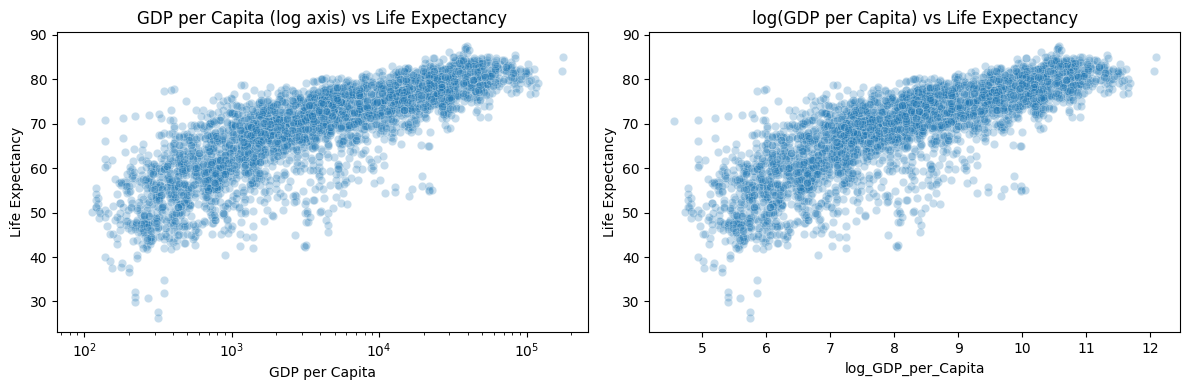

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# correlation comparison
if "GDP per Capita" in df_fe.columns and "log_GDP_per_Capita" in df_fe.columns:
    corr_raw = df_fe[["GDP per Capita", target_col]].corr().iloc[0,1]
    corr_log = df_fe[["log_GDP_per_Capita", target_col]].corr().iloc[0,1]
    print(f"Corr(LifeExp, GDP per Capita)     = {corr_raw:.3f}")
    print(f"Corr(LifeExp, log_GDP_per_Capita) = {corr_log:.3f}")

# scatterplots (use sample for speed)
plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=plot_df, x="GDP per Capita", y=target_col, alpha=0.25, ax=ax[0])
ax[0].set_xscale("log")
ax[0].set_title("GDP per Capita (log axis) vs Life Expectancy")

sns.scatterplot(data=plot_df, x="log_GDP_per_Capita", y=target_col, alpha=0.25, ax=ax[1])
ax[1].set_title("log(GDP per Capita) vs Life Expectancy")

plt.tight_layout()
plt.show()


,Life Expectancy
Infant Mortality Rate,-0.911721
Maternal Mortality Ratio,-0.809229
Life Expectancy,1.000000


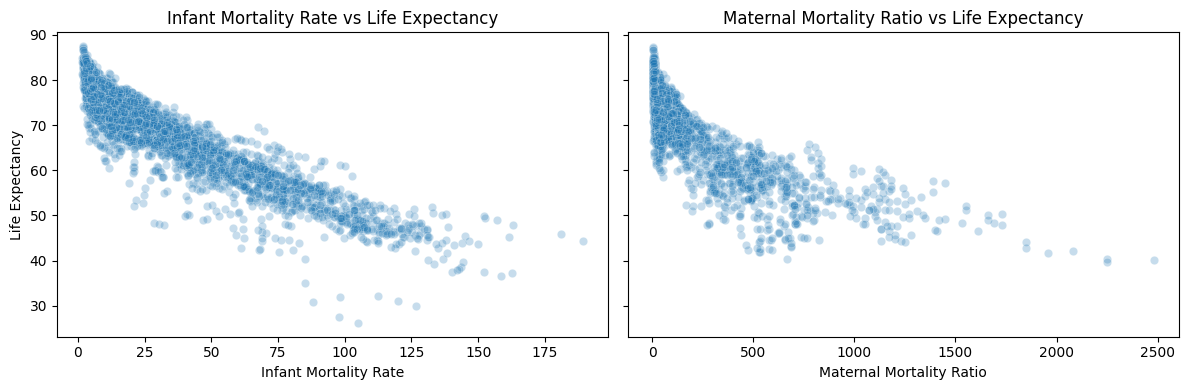

In [48]:
# Mortality variables vs Life Expectancy (side-by-side)
mortality_vars = [
    c for c in ["Infant Mortality Rate", "Maternal Mortality Ratio"]
    if c in df_fe.columns
]

# Correlation table (quantitative check)
display(
    df_fe[mortality_vars + [target_col]]
    .corr()[target_col]
    .sort_values()
)

# Sample for plotting
plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, axes = plt.subplots(1, len(mortality_vars), figsize=(12,4), sharey=True)

for ax, v in zip(axes, mortality_vars):
    sns.scatterplot(
        data=plot_df,
        x=v,
        y=target_col,
        alpha=0.25,
        ax=ax
    )
    ax.set_title(f"{v} vs Life Expectancy")
    ax.set_xlabel(v)

axes[0].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()

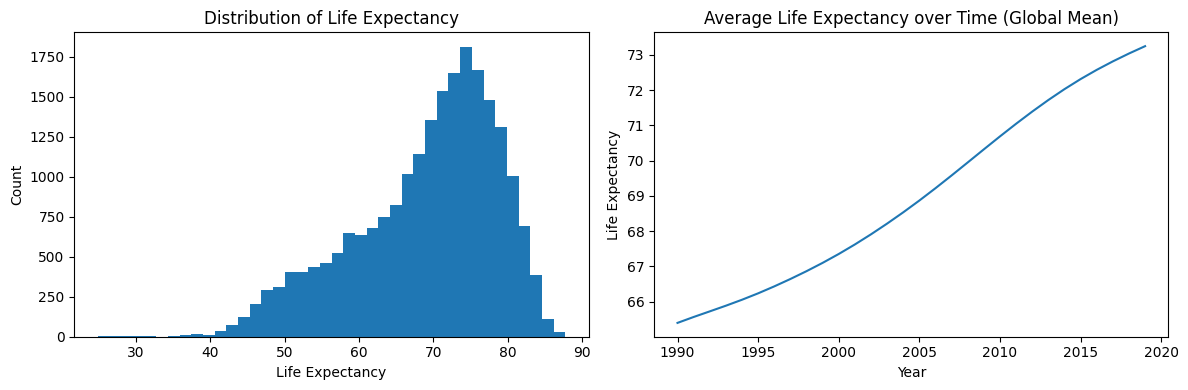

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Life Expectancy distribution
axes[0].hist(df["Life Expectancy"], bins=40)
axes[0].set_xlabel("Life Expectancy")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Life Expectancy")

# Global time trend
if "Year" in df_fe.columns:
    df_fe.groupby("Year")[target_col].mean().plot(ax=axes[1])
    axes[1].set_title("Average Life Expectancy over Time (Global Mean)")
    axes[1].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,71.072531,0.621761,114.308422,0.000000e+00,69.853738,72.291323
log_GDP_per_Capita,0.523144,0.062837,8.325389,9.630226e-17,0.399969,0.646319
Infant Mortality Rate,-0.243339,0.002286,-106.459728,0.000000e+00,-0.247819,-0.238858
animal_to_plant_protein_ratio,-0.960424,0.372757,-2.576540,9.995190e-03,-1.691113,-0.229735
Diet Calories Animal Protein,0.017338,0.002580,6.718922,1.941365e-11,0.012280,0.022396
Diet Calories Plant Protein,-0.002653,0.002126,-1.247679,2.121810e-01,-0.006821,0.001515


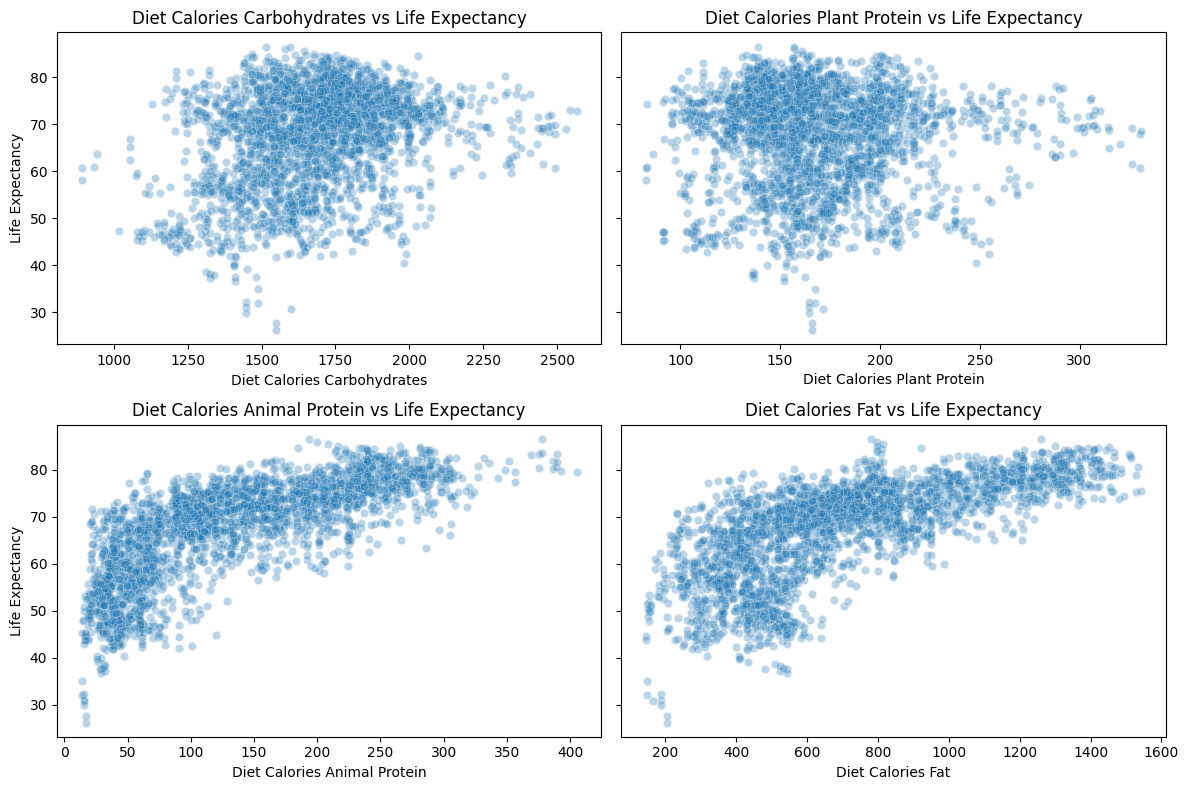

In [54]:
# --- Linear regression with nutrition controls (unchanged) ---
nutri_cols = [
    c for c in [
        "animal_to_plant_protein_ratio",
        "Diet Calories Animal Protein",
        "Diet Calories Plant Protein"
    ]
    if c in df_fe.columns
]

controls = [
    c for c in ["log_GDP_per_Capita", "Infant Mortality Rate"]
    if c in df_fe.columns
]

tmp = df_fe[nutri_cols + controls + [target_col]].dropna()

X = sm.add_constant(tmp[controls + nutri_cols])
y = tmp[target_col]
m = sm.OLS(y, X).fit()

display(m.summary2().tables[1])


# --- Nutrition scatterplots (2x2 layout) ---
nutrition_vars = [
    c for c in [
        "Diet Calories Carbohydrates",
        "Diet Calories Plant Protein",
        "Diet Calories Animal Protein",
        "Diet Calories Fat",
    ]
    if c in df_fe.columns
]

plot_df = df_fe.sample(min(5000, len(df_fe)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=True)
axes = axes.flatten()

for ax, var in zip(axes, nutrition_vars):
    sns.scatterplot(
        data=plot_df,
        x=var,
        y=target_col,
        alpha=0.30,
        ax=ax
    )
    ax.set_title(f"{var} vs Life Expectancy")
    ax.set_xlabel(var)

# Remove unused axes if fewer than 4 variables
for ax in axes[len(nutrition_vars):]:
    ax.axis("off")

axes[0].set_ylabel("Life Expectancy")
axes[2].set_ylabel("Life Expectancy")

plt.tight_layout()
plt.show()


Correlation analysis (what I do / how to interpret):

I compute correlations only on numeric columns (correlation ≠ causation).

Very strong correlations are expected here because development indicators move together:

positive: UHC, water, sanitation, log GDP, clean fuel

negative: infant mortality, maternal mortality, dependency ratio

If many features are highly correlated, linear models can still work, but coefficients may be unstable → that’s why I also compare tree/boosting models and add PCA/ICA.

Top + correlations:


,Life Expectancy
Life Expectancy,1.000000
Universal Heath Care Coverage,0.846801
Basic Sanization Services Total,0.821638
Basic Drinking Water Services,0.803670
log_GDP_per_Capita,0.796441
Clean Fuel and Technology,0.768905
% Population Aged 15-64,0.743820
Diet Calories Animal Protein,0.729547
Diet Calories Fat,0.696256
% Population Aged 65+,0.677503


Top - correlations:


,Life Expectancy
Diet Calories Animal Protein,0.729547
Diet Calories Fat,0.696256
% Population Aged 65+,0.677503
animal_to_plant_protein_ratio,0.658549
GDP per Capita,0.550229
Diet Calories Carbohydrates,0.270867
Year,0.260710
Diet Calories Plant Protein,-0.009344
dependency_ratio,-0.768227
Maternal Mortality Ratio,-0.809229


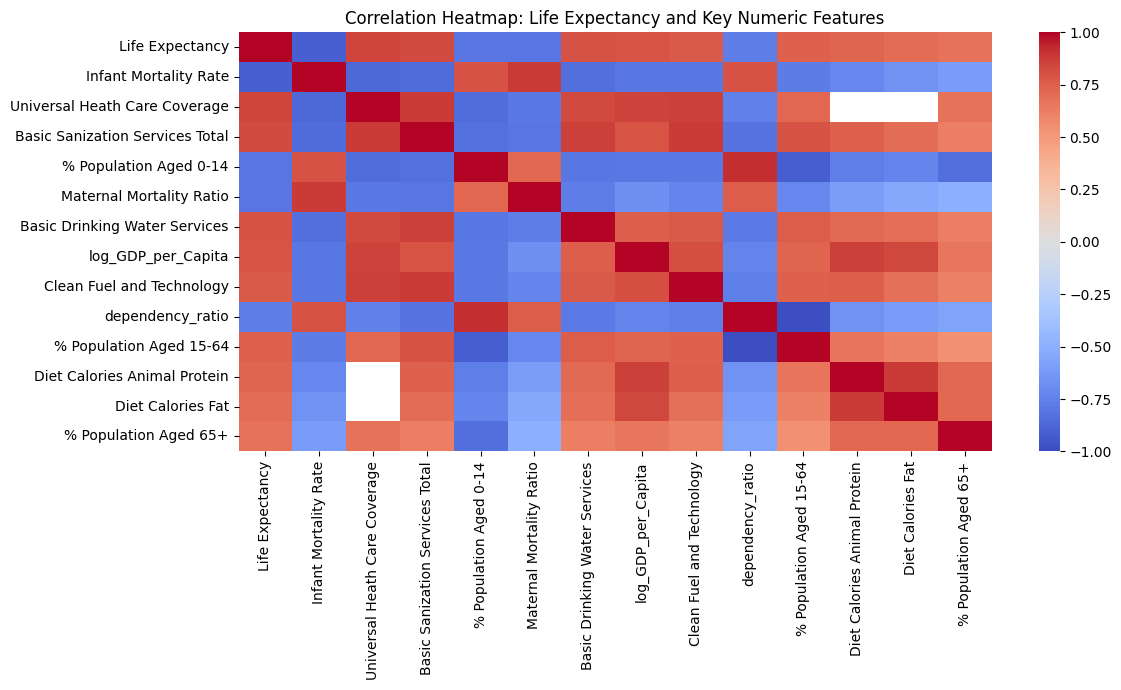

In [8]:
num_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df_fe[num_cols].corr()[target_col].sort_values(ascending=False)

print("Top + correlations:")
display(corr_target.head(12))

print("Top - correlations:")
display(corr_target.tail(12))

top_feats = corr_target.abs().sort_values(ascending=False).head(14).index.tolist()
top_feats = [c for c in top_feats if c != target_col]
plt.figure(figsize=(12,7))
sns.heatmap(df_fe[[target_col] + top_feats].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Life Expectancy and Key Numeric Features")
plt.tight_layout()
plt.show()


Modeling setup (important fixes included):

I use a single preprocessing pipeline:

numeric → median imputation + standardization

categorical → most-frequent imputation + one-hot encoding

Fix for your error: HistGradientBoostingRegressor does not accept sparse matrices → I force dense output by:

OneHotEncoder(..., sparse_output=False)

ColumnTransformer(..., sparse_threshold=0.0)

Models (5 total, chosen for speed + diversity):

LinearRegression (baseline)

Ridge (regularized linear)

Lasso (sparse linear)

RandomForest (nonlinear, robust)

HistGradientBoosting (fast boosting, strong performance)

In [9]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

X = df_fe[features_final].copy()
y = df_fe[target_col].copy()

num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_feats),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_feats)
    ],
    sparse_threshold=0.0  # force dense output overall
)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

def adjusted_r2(r2, n, p):
    # adjusted R2 = 1 - (1-R2)*(n-1)/(n-p-1)
    # p should be number of model inputs after preprocessing; we approximate using transformed feature count.
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate_model(pipe, X_tr, X_te, y_tr, y_te):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    mse = mean_squared_error(y_te, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, pred)

    # approximate p using transformed feature dimension
    Xt = pipe.named_steps["prep"].transform(X_tr)
    p = Xt.shape[1]
    n = len(y_te)

    return {
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2(approx)": adjusted_r2(r2, n=n, p=p)
    }


Model evaluation strategy (3 splits)

To avoid “too good to be true” results, I evaluate models under 3 different splits:

Random split (standard ML): mixes countries/years → easiest setting.

Time split (train on older years, test on newer years): checks if the model generalizes to the future.

Country split (group split by Country): hardest and most realistic generalization test, because the model must predict for countries it never saw during training.

Metrics:

MAE: average absolute error in years of life expectancy

RMSE: penalizes large errors

R²: explained variance

Adj R² (approx): adjusted for number of features (approx because preprocessing changes dimension)

In [10]:
results = []

# -----------------------
# 1) RANDOM SPLIT
# -----------------------
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    m = evaluate_model(pipe, X_tr, X_te, y_tr, y_te)
    m.update({"split": "random", "model": name})
    results.append(m)

# -----------------------
# 2) TIME SPLIT
# -----------------------
if "Year" in df_fe.columns:
    cutoff = 2012
    tr_mask = df_fe["Year"] <= cutoff
    te_mask = df_fe["Year"] > cutoff

    # Only evaluate if we have both sides non-empty
    if tr_mask.sum() > 0 and te_mask.sum() > 0:
        for name, model in models.items():
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            m = evaluate_model(pipe, X.loc[tr_mask], X.loc[te_mask], y.loc[tr_mask], y.loc[te_mask])
            m.update({"split": "time", "model": name})
            results.append(m)

# -----------------------
# 3) COUNTRY SPLIT
# -----------------------
if "Country" in df_fe.columns:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=df_fe["Country"]))

    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        m = evaluate_model(pipe, X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx])
        m.update({"split": "country", "model": name})
        results.append(m)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["split", "MAE"]).reset_index(drop=True)

display(results_df)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Universal Heath Care Coverage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Universal Heath Care Coverage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Universal Heath Care Coverage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Universal Heath Care Coverage']. At least one non-missing value is needed for imputati

,MAE,RMSE,R2,Adj_R2(approx),split,model
0,3.129292,4.674848,0.779699,0.767435,country,HistGradientBoosting
1,3.195300,5.136965,0.733992,0.719183,country,RandomForest
2,4.952663,7.030590,0.501730,0.473991,country,Lasso
3,5.561131,7.454440,0.439841,0.408656,country,Ridge
4,6.257951,8.184886,0.324685,0.287089,country,Linear
5,0.539698,0.917692,0.991218,0.990579,random,RandomForest
6,1.219676,1.600902,0.973275,0.971331,random,HistGradientBoosting
7,1.267603,1.943112,0.960628,0.957764,random,Linear
8,1.298468,1.956210,0.960096,0.957193,random,Ridge
9,1.415947,2.044386,0.956417,0.953247,random,Lasso


1) Random split is extremely optimistic

Random split results are very high (e.g., RandomForest R² ≈ 0.991).

That’s because the model sees the same countries in train and test, and many indicators are stable within a country.

2) Time split is harder (still good)

R² drops to around 0.88–0.93 depending on model.

This is more realistic: you’re forecasting future years using past patterns.

3) Country split is the real test

This is the key: performance drops a lot because the model must generalize to new countries.

Best in your table is HistGradientBoosting with R² ≈ 0.78 and MAE ≈ 3.13 years

RandomForest is slightly worse under country split (R² ≈ 0.73)

In [11]:
# Pretty display (rounded) + best model per split
pretty = results_df.copy()
pretty["MAE"] = pretty["MAE"].round(3)
pretty["RMSE"] = pretty["RMSE"].round(3)
pretty["R2"] = pretty["R2"].round(3)
pretty["Adj_R2(approx)"] = pretty["Adj_R2(approx)"].round(3)

display(pretty)

print("\nBest model per split (lowest MAE):")
display(pretty.sort_values(["split", "MAE"]).groupby("split").head(1))


,MAE,RMSE,R2,Adj_R2(approx),split,model
0,3.129,4.675,0.780,0.767,country,HistGradientBoosting
1,3.195,5.137,0.734,0.719,country,RandomForest
2,4.953,7.031,0.502,0.474,country,Lasso
3,5.561,7.454,0.440,0.409,country,Ridge
4,6.258,8.185,0.325,0.287,country,Linear
5,0.540,0.918,0.991,0.991,random,RandomForest
6,1.220,1.601,0.973,0.971,random,HistGradientBoosting
7,1.268,1.943,0.961,0.958,random,Linear
8,1.298,1.956,0.960,0.957,random,Ridge
9,1.416,2.044,0.956,0.953,random,Lasso



Best model per split (lowest MAE):


,MAE,RMSE,R2,Adj_R2(approx),split,model
0,3.129,4.675,0.780,0.767,country,HistGradientBoosting
5,0.540,0.918,0.991,0.991,random,RandomForest
10,1.588,2.136,0.928,0.923,time,RandomForest


Why the country split drops so much

This doesn’t mean the model is bad — it means:

Countries have structural differences (institutions, geography, measurement quality, conflict, etc.) not fully captured by your features.

Variables like GDP, sanitation, water, and mortality are partially proxies for “development level,” but development pathways differ.

Including Country helps on random split because it acts like an identifier → boosts performance, but it’s not “true causal prediction”.

To show this more clearly, I run one extra experiment:

model with Country

model without Country
and compare results (especially in random split).

In [12]:
from sklearn.base import clone

def run_one_split_compare(include_country=True):
    feat_use = features_final.copy()
    if not include_country and "Country" in feat_use:
        feat_use.remove("Country")

    X2 = df_fe[feat_use].copy()
    y2 = df_fe[target_col].copy()

    num2 = X2.select_dtypes(include=[np.number]).columns.tolist()
    cat2 = X2.select_dtypes(include=["object"]).columns.tolist()

    prep2 = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num2),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat2)
        ],
        sparse_threshold=0.0
    )

    Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=42)

    rows = []
    for name, model in models.items():
        pipe = Pipeline([("prep", prep2), ("model", clone(model))])
        m = evaluate_model(pipe, Xtr, Xte, ytr, yte)
        m.update({"setting": "with_country" if include_country else "no_country", "model": name})
        rows.append(m)
    return pd.DataFrame(rows)

comp_with = run_one_split_compare(include_country=True)
comp_without = run_one_split_compare(include_country=False)

comp = pd.concat([comp_with, comp_without], axis=0)
comp["MAE"] = comp["MAE"].round(3)
comp["RMSE"] = comp["RMSE"].round(3)
comp["R2"] = comp["R2"].round(3)
comp["Adj_R2(approx)"] = comp["Adj_R2(approx)"].round(3)

display(comp.sort_values(["setting", "MAE"]))


,MAE,RMSE,R2,Adj_R2(approx),setting,model
4,1.804,3.421,0.878,0.877,no_country,RandomForest
3,2.246,3.586,0.866,0.865,no_country,HistGradientBoosting
0,3.700,5.079,0.731,0.730,no_country,Linear
1,3.700,5.079,0.731,0.730,no_country,Ridge
2,3.700,5.079,0.731,0.730,no_country,Lasso
4,0.540,0.918,0.991,0.991,with_country,RandomForest
3,1.220,1.601,0.973,0.971,with_country,HistGradientBoosting
0,1.268,1.943,0.961,0.958,with_country,Linear
1,1.298,1.956,0.960,0.957,with_country,Ridge
2,1.416,2.044,0.956,0.953,with_country,Lasso


H4: Infrastructure partially mediates income effects (simple coefficient check)

Idea: If GDP works partly through better infrastructure (water/sanitation/clean fuel/UHC), then the GDP coefficient should shrink when we add infrastructure variables.

We run two simple OLS models:
- Model A: LifeExp ~ log GDP
- Model B: LifeExp ~ log GDP + infrastructure


In [49]:
import statsmodels.api as sm

# Choose available columns
base_cols = [c for c in ["log_GDP_per_Capita"] if c in df_fe.columns]
infra_cols = [c for c in [
    "Basic Drinking Water Services",
    "Basic Sanization Services Total",
    "Clean Fuel and Technology",
    "Universal Heath Care Coverage"
] if c in df_fe.columns]

tmp = df_fe[base_cols + infra_cols + [target_col]].dropna()

X_A = sm.add_constant(tmp[base_cols])
y_A = tmp[target_col]
mA = sm.OLS(y_A, X_A).fit()

X_B = sm.add_constant(tmp[base_cols + infra_cols])
y_B = tmp[target_col]
mB = sm.OLS(y_B, X_B).fit()

print("Model A (LifeExp ~ logGDP)")
print(mA.params)
print("\nModel B (LifeExp ~ logGDP + infrastructure)")
print(mB.params)

print("\nlogGDP coefficient shrinkage:")
print("A:", mA.params["log_GDP_per_Capita"])
print("B:", mB.params["log_GDP_per_Capita"])


Model A (LifeExp ~ logGDP)
const                 31.740627
log_GDP_per_Capita     4.648551
dtype: float64

Model B (LifeExp ~ logGDP + infrastructure)
const                              38.312208
log_GDP_per_Capita                  1.439311
Basic Drinking Water Services       0.098750
Basic Sanization Services Total     0.038998
Clean Fuel and Technology          -0.010738
Universal Heath Care Coverage       0.171826
dtype: float64

logGDP coefficient shrinkage:
A: 4.648551096039047
B: 1.439311150247692


Multivariate analysis: PCA and ICA

Now we move beyond pairwise plots and do true multivariate structure analysis.

PCA finds orthogonal directions that explain the most variance.

Often PC1 becomes a “development axis” combining mortality, sanitation, clean fuel, GDP, etc.

ICA tries to find statistically independent latent signals.

Often separates “mortality/infrastructure” vs “diet transition” components.

Important:

PCA/ICA are done only on numeric features (scaled).

Categorical features (Country, Gender) are excluded.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# numeric-only for PCA/ICA
X_num = df_fe[features_final].select_dtypes(include=[np.number]).copy()
y_all = df_fe[target_col].copy()

print("Numeric feature matrix shape:", X_num.shape)

# Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_num_imp = imputer.fit_transform(X_num)
X_num_scaled = scaler.fit_transform(X_num_imp)

X_num_scaled = pd.DataFrame(X_num_scaled, columns=X_num.columns, index=df_fe.index)
display(X_num_scaled.head())


Numeric feature matrix shape: (22050, 15)


,Year,log_GDP_per_Capita,Infant Mortality Rate,Maternal Mortality Ratio,% Population Aged 15-64,dependency_ratio,Universal Heath Care Coverage,Basic Drinking Water Services,Basic Sanization Services Total,Clean Fuel and Technology,Diet Calories Animal Protein,Diet Calories Plant Protein,animal_to_plant_protein_ratio,Diet Calories Fat,Diet Calories Carbohydrates
0,-1.675247,-0.019098,3.387491,-0.296017,-1.999905,2.251326,0.06411,0.252283,0.294801,0.346678,-0.988210,1.088367,-1.032733,-1.065949,-0.413564
1,-1.675247,-0.019098,3.156473,-0.296017,-1.981291,2.224023,0.06411,0.252283,0.294801,0.346678,-0.988210,1.088367,-1.032733,-1.065949,-0.413564
2,-1.675247,-0.019098,3.603605,-0.296017,-2.017710,2.277563,0.06411,0.252283,0.294801,0.346678,-0.988210,1.088367,-1.032733,-1.065949,-0.413564
3,-1.559712,-0.019098,3.253351,-0.296017,-1.986837,2.232145,0.06411,0.252283,0.294801,0.346678,-1.035074,0.248996,-0.962750,-1.341973,-1.452330
4,-1.559712,-0.019098,3.026059,-0.296017,-1.972937,2.211811,0.06411,0.252283,0.294801,0.346678,-1.035074,0.248996,-0.962750,-1.341973,-1.452330


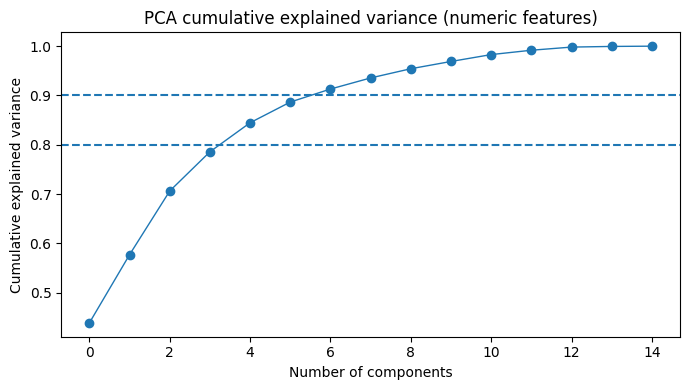

Components for 80% variance: 5
Components for 90% variance: 7


In [14]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_num_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(7,4))
plt.plot(cum_explained, marker="o", linewidth=1)
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.title("PCA cumulative explained variance (numeric features)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

k90 = int(np.argmax(cum_explained >= 0.90) + 1)
k80 = int(np.argmax(cum_explained >= 0.80) + 1)

print(f"Components for 80% variance: {k80}")
print(f"Components for 90% variance: {k90}")


PCA interpretation

Found k=7 components for ~90% variance — that’s actually a strong result:

it means 15 numeric indicators compress into a small number of “latent development factors”.

From  loadings:

PC1 loads strongly on mortality + dependency vs GDP/sanitation/water/clean fuel
→ interpretable as “overall development + survival conditions”

PC2 loads strongly on plant protein and carbohydrates vs animal protein ratio
→ interpretable as “diet composition axis”

PC3 mixes year + carbs/plant protein and some infrastructure
→ could represent “time-driven global changes + diet shift”

In [59]:
k = min(k90, 7)  # keep consistent with your result (7)

pca = PCA(n_components=k, random_state=42)
X_pca = pca.fit_transform(X_num_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_num.columns,
    columns=[f"PC{i+1}" for i in range(k)]
)

def show_top_loadings(component, top_n=12):
    s = loadings[component].sort_values(key=np.abs, ascending=False).head(top_n)
    display(s)

print("Top loadings for PC1:")
show_top_loadings("PC1")

print("Top loadings for PC2:")
show_top_loadings("PC2")

print("Top loadings for PC3:")
show_top_loadings("PC3")


Top loadings for PC1:


,PC1
dependency_ratio,0.321851
% Population Aged 15-64,-0.317662
log_GDP_per_Capita,-0.315323
Basic Sanization Services Total,-0.310933
Basic Drinking Water Services,-0.301355
Infant Mortality Rate,0.298725
Clean Fuel and Technology,-0.297079
Diet Calories Animal Protein,-0.296136
Maternal Mortality Ratio,0.283107
Diet Calories Fat,-0.275456


Top loadings for PC2:


,PC2
Diet Calories Plant Protein,0.471281
animal_to_plant_protein_ratio,-0.451108
Diet Calories Carbohydrates,0.410359
Diet Calories Animal Protein,-0.339247
Diet Calories Fat,-0.297896
Maternal Mortality Ratio,-0.210462
Basic Sanization Services Total,0.188992
Basic Drinking Water Services,0.184007
Universal Heath Care Coverage,0.179617
Clean Fuel and Technology,0.178379


Top loadings for PC3:


,PC3
Diet Calories Carbohydrates,0.403121
Year,0.390455
Diet Calories Plant Protein,0.343987
Basic Sanization Services Total,-0.301054
Clean Fuel and Technology,-0.299122
Maternal Mortality Ratio,0.275329
Basic Drinking Water Services,-0.272406
% Population Aged 15-64,0.217349
dependency_ratio,-0.213041
Universal Heath Care Coverage,-0.209516


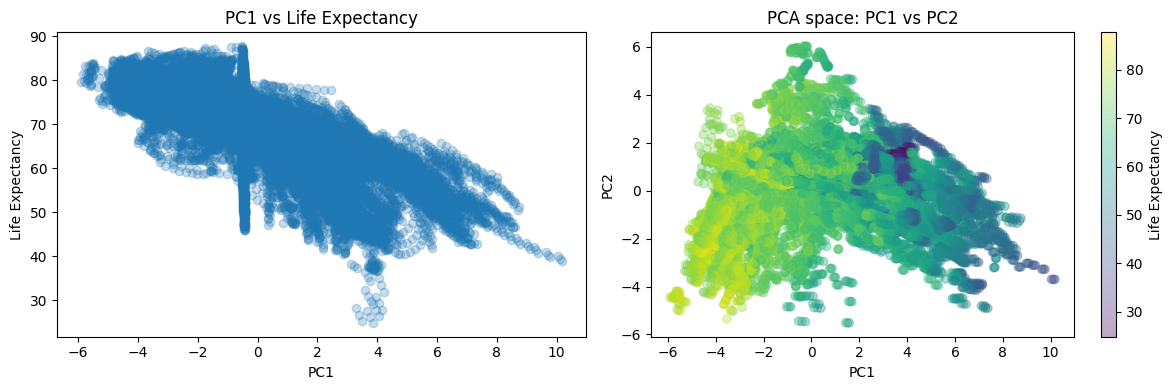

In [62]:
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(k)], index=df_fe.index)
pca_df[target_col] = y_all.values

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# PC1 vs Life Expectancy
axes[0].scatter(pca_df["PC1"], pca_df[target_col], alpha=0.25)
axes[0].set_title("PC1 vs Life Expectancy")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("Life Expectancy")

# PC1 vs PC2 colored by Life Expectancy
sc = axes[1].scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df[target_col],
    alpha=0.35
)
axes[1].set_title("PCA space: PC1 vs PC2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="Life Expectancy")

plt.tight_layout()
plt.show()



Convert PCA scores to DataFrame

Country-level PCA matrix shape: (281, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Country,,,,,,,
Afghanistan,4.939528,-0.985524,-0.324503,-0.075162,0.108058,0.615919,0.819754
Africa,-0.470676,0.405424,-0.282559,0.295793,-0.151824,-0.153597,-0.111959
Albania,-0.822144,0.586488,0.492088,-0.499100,-0.174167,-0.117952,-0.162574
Algeria,0.007350,2.634094,0.765722,-0.889386,0.053872,0.347055,0.161744
American Samoa,-0.615614,0.370913,-0.215085,0.350443,-0.108549,-0.092875,0.013208


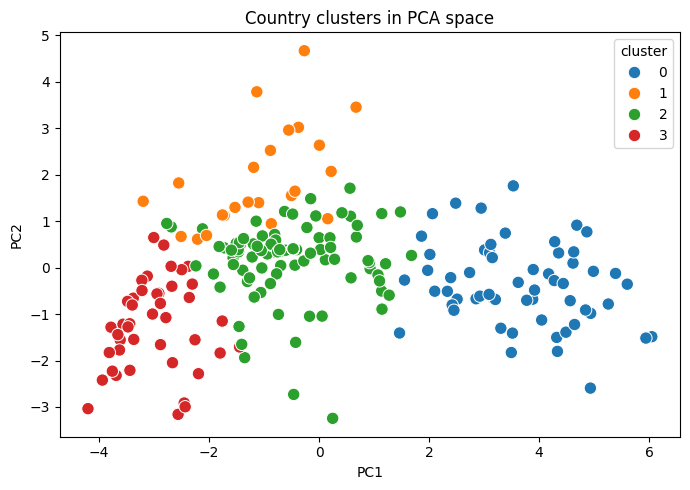

In [63]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(k)],
    index=df_fe.index
)

pca_df["Country"] = df_fe["Country"]

country_pca = (
    pca_df
    .groupby("Country")
    .mean()
)

print("Country-level PCA matrix shape:", country_pca.shape)
display(country_pca.head())

from sklearn.cluster import KMeans

k_clusters = 4  # 3–5 is reasonable, 4 usually works well

kmeans = KMeans(
    n_clusters=k_clusters,
    random_state=42,
    n_init=10
)

country_pca["cluster"] = kmeans.fit_predict(country_pca)
country_pca["cluster"].value_counts()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=country_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=80
)
plt.title("Country clusters in PCA space")
plt.tight_layout()
plt.show()



In [29]:
country_profile = (
    df_fe
    .groupby("Country")[[
        "Life Expectancy",
        "log_GDP_per_Capita",
        "Infant Mortality Rate",
        "dependency_ratio",
        "Diet Calories Animal Protein"
    ]]
    .mean()
    .join(country_pca["cluster"])
    .groupby("cluster")
    .mean()
)

display(country_profile)


,Life Expectancy,log_GDP_per_Capita,Infant Mortality Rate,dependency_ratio,Diet Calories Animal Protein
cluster,,,,,
0,56.860324,6.498495,71.234261,0.864218,53.690833
1,72.083200,8.427617,20.503743,0.507090,131.070935
2,71.533352,8.621552,21.054701,0.593858,128.900496
3,77.583955,10.002244,6.601830,0.510348,244.207820


In [44]:
# country_pca is indexed by country names, so just convert index -> column
country_pca = country_pca.reset_index()

# rename safely
if "index" in country_pca.columns:
    country_pca = country_pca.rename(columns={"index": "Country"})

country_pca.head()

,Country,PC1,PC2,PC3,PC4,PC5,PC6,PC7,cluster
0,Afghanistan,4.939528,-0.985524,-0.324503,-0.075162,0.108058,0.615919,0.819754,0
1,Africa,-0.470676,0.405424,-0.282559,0.295793,-0.151824,-0.153597,-0.111959,2
2,Albania,-0.822144,0.586488,0.492088,-0.499100,-0.174167,-0.117952,-0.162574,2
3,Algeria,0.007350,2.634094,0.765722,-0.889386,0.053872,0.347055,0.161744,1
4,American Samoa,-0.615614,0.370913,-0.215085,0.350443,-0.108549,-0.092875,0.013208,2


In [45]:
for c in sorted(country_pca["cluster"].unique()):
    sample = country_pca.loc[country_pca["cluster"] == c, "Country"].head(8).tolist()
    print(f"Cluster {c} example countries:", sample)

Cluster 0 example countries: ['Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon']
Cluster 1 example countries: ['Algeria', 'Azerbaijan', 'Bosnia and Herzegovina', 'China', 'Cuba', 'Egypt', 'Georgia', 'Iran']
Cluster 2 example countries: ['Africa', 'Albania', 'American Samoa', 'Americas', 'Andorra', 'Anguilla', 'Armenia', 'Aruba']
Cluster 3 example countries: ['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belarus', 'Belgium']
